In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

In [30]:
df=pd.read_csv('/content/drive/MyDrive/spam_classifier/spam.csv',encoding='latin-1')


print(df.head())
df.shape


     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  


(5572, 5)

#1.Cleaning data

In [31]:
df=df[['v1','v2']]
df.columns=['label','message']

In [32]:
df.isnull().sum()

,0
label,0
message,0


In [33]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


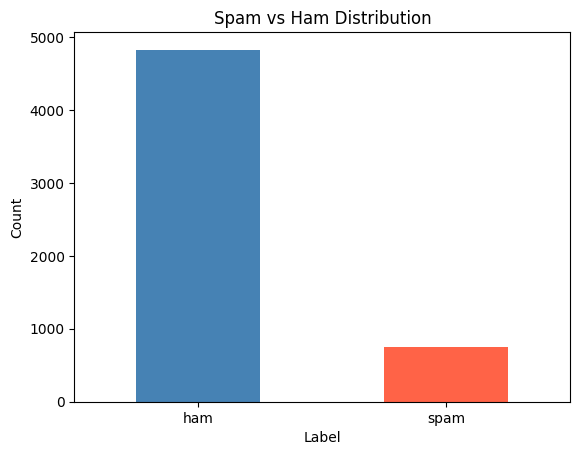

In [34]:

df['label'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

#2.Data Preprocessing

##1.Convert labels to numbers

In [35]:
df['label_enc']=df['label'].map({'spam':1,'ham':0})
df.head()

,label,message,label_enc
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


##2.Clean the data

In [36]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
def clean_text(text):
  text=text.lower()
  text=re.sub(r'[^a-z\s]','',text)
  stop_words=stopwords.words('english')
  text=' '.join([word for word in text.split() if word not in stop_words])
  return text
  pass

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
df['clean_msg']=df['message'].apply(clean_text)
df[['message','clean_msg']].head()

,message,clean_msg
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


#3.Feature Engineering-TF-IDF

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf=TfidfVectorizer(max_features=3000)
# TF-IDF converts text to numbers based on word importance
# max_features=3000 keeps only top 3000 most important words
X = tfidf.fit_transform(df['clean_msg'])
y=df['label_enc']

In [39]:
print(X.shape)
print(y.shape)

(5572, 3000)
(5572,)


#4.Model training

###Train/Test split

In [41]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4457, 3000)
(1115, 3000)
(4457,)
(1115,)


##1.Naive Bayes

In [43]:
from sklearn.naive_bayes import MultinomialNB
nb=MultinomialNB()
nb.fit(X_train,y_train)

y_pred_nb=nb.predict(X_test)

print(accuracy_score(y_test,y_pred_nb))
print(classification_report(y_test,y_pred_nb))


0.9748878923766816
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       965
           1       1.00      0.81      0.90       150

    accuracy                           0.97      1115
   macro avg       0.99      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115



##2.Logistic Regression

In [45]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print(accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

0.9479820627802691
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       0.96      0.64      0.77       150

    accuracy                           0.95      1115
   macro avg       0.95      0.82      0.87      1115
weighted avg       0.95      0.95      0.94      1115



#5.Confusion Matrix

###Naive bayes

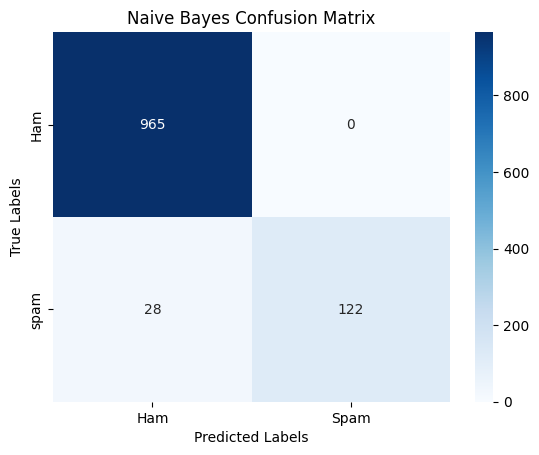

In [48]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,y_pred_nb)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Ham','Spam'],
            yticklabels=['Ham','spam'])
plt.title('Naive Bayes Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

###Logistic Regression

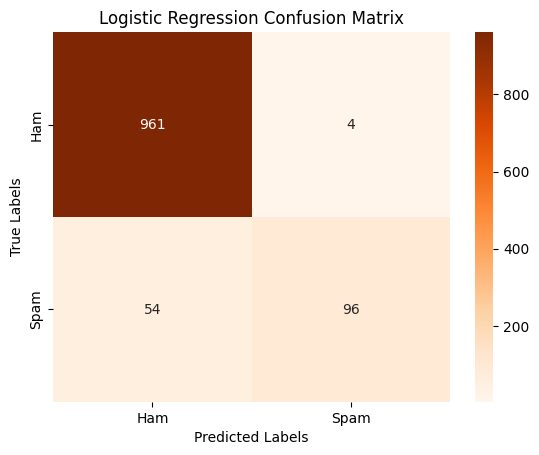

In [49]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Logistic Regression Confusion Matrix')
plt.ylabel('True Labels')
plt.xlabel('Predicted Labels')
plt.show()

#6.Prediction Function

In [55]:
def predict_message(m):
  cleaned=clean_text(m)
  vectorized=tfidf.transform([cleaned])

  prediction=nb.predict(vectorized)[0]

  if prediction==1:
    return 'Spam'
  else:
    return 'Ham'

In [56]:
print(predict_message("Congratulations! You won a free prize call now!"))
print(predict_message("Hey, are we still meeting for lunch tomorrow?"))
print(predict_message("WINNER!! Claim your £1000 cash reward now!"))

Spam
Ham
Spam


#7.Saving the Model with Pickle

In [58]:
import pickle

with open('spam_classifier.pkl', 'wb') as f:
    pickle.dump(nb, f)

with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Models saved successfully!")

Models saved successfully!


In [59]:
# Load and test
with open('spam_classifier.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('tfidf_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

# Test loaded model
msg = "Free entry win cash prize now!"
cleaned = clean_text(msg)
vectorized = loaded_tfidf.transform([cleaned])
print(loaded_model.predict(vectorized)[0])

1
